# Bahraini Currency Classification with Neural Networks

Three models are built and compared, each with its own prediction and error analysis:

1. **Sequential API** — Flatten + Dense
2. **Functional API** — Flatten + Dense
3. **CNN** — Conv2D + MaxPooling

## Setup

In [ ]:
# In Colab I upload dataset_final.zip here.
# On my laptop the folder is already next to the notebook, so this is skipped.
import os

IN_COLAB = os.path.exists('/content')

if IN_COLAB and not os.path.exists('dataset_final.zip'):
    from google.colab import files
    uploaded = files.upload()
    print(uploaded.keys())
else:
    print("dataset_final.zip is already here")

In [ ]:
# -o means overwrite the old files without stopping to ask.
# Without it, running this a second time waits forever for an answer.
if IN_COLAB:
    !unzip -q -o dataset_final.zip -d /content/
    base = '/content/dataset_final'
else:
    base = 'dataset_final'

print(base)
os.listdir(base)

In [3]:
total = 0
for folder in sorted(os.listdir(base)):
    n = len(os.listdir(os.path.join(base, folder)))
    total += n
    print(folder, n)
print("TOTAL:", total)

0.5 BHD 300
1 BHD 300
10 BHD 300


20 BHD 300
5 BHD 300
TOTAL: 1500


## Loading the Data

Fashion MNIST gave us `x_train` / `y_train` arrays directly. Our images are in
folders, so we load them and turn them into arrays ourselves.

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
import numpy as np

IMG_SIZE = (64, 64)

full = image_dataset_from_directory(
    base,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True,
    seed=123
)

class_names = full.class_names

X = []
y = []
for images, labels in full:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X, dtype='uint8')
y = np.array(y)

X.shape, y.shape

Found 1500 files belonging to 5 classes.


((1500, 64, 64, 3), (1500,))

The folders are read in **alphabetical** order, so `10 BHD` comes before `5 BHD`.
Copy this list into the Streamlit app exactly as printed.

In [5]:
class_names

['0.5 BHD', '1 BHD', '10 BHD', '20 BHD', '5 BHD']

In [6]:
#split to train, val and test

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2,
                                                  random_state=42, stratify=y_train)

x_train.shape, x_val.shape, x_test.shape

((960, 64, 64, 3), (240, 64, 64, 3), (300, 64, 64, 3))

## Looking at the Data

In [7]:
x_train.shape

(960, 64, 64, 3)

In [8]:
x_train[0]

array([[[26, 26, 26],
        [29, 29, 29],
        [27, 27, 27],
        ...,
        [11, 11, 11],
        [15, 15, 15],
        [16, 16, 16]],

       [[23, 23, 23],
        [26, 26, 26],
        [26, 26, 26],
        ...,
        [17, 17, 17],
        [16, 16, 16],
        [14, 14, 14]],

       [[23, 23, 23],
        [20, 20, 20],
        [27, 27, 27],
        ...,
        [17, 17, 17],
        [18, 18, 18],
        [16, 16, 16]],

       ...,

       [[15, 15, 15],
        [16, 16, 16],
        [15, 15, 15],
        ...,
        [13, 13, 13],
        [11, 11, 11],
        [11, 11, 11]],

       [[14, 14, 14],
        [15, 15, 15],
        [11, 11, 11],
        ...,
        [10, 10, 10],
        [16, 16, 16],
        [12, 12, 12]],

       [[11, 11, 11],
        [13, 13, 13],
        [18, 18, 18],
        ...,
        [ 7,  7,  7],
        [14, 14, 14],
        [ 9,  9,  9]]], shape=(64, 64, 3), dtype=uint8)

In [9]:
y_train[0]

np.int32(4)

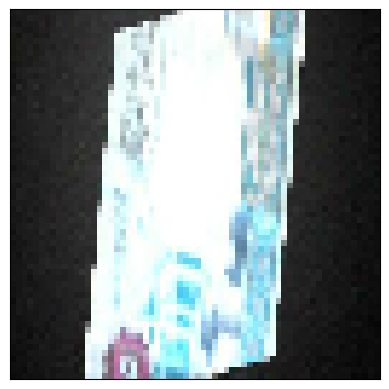

In [10]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.xticks([])
plt.yticks([]);

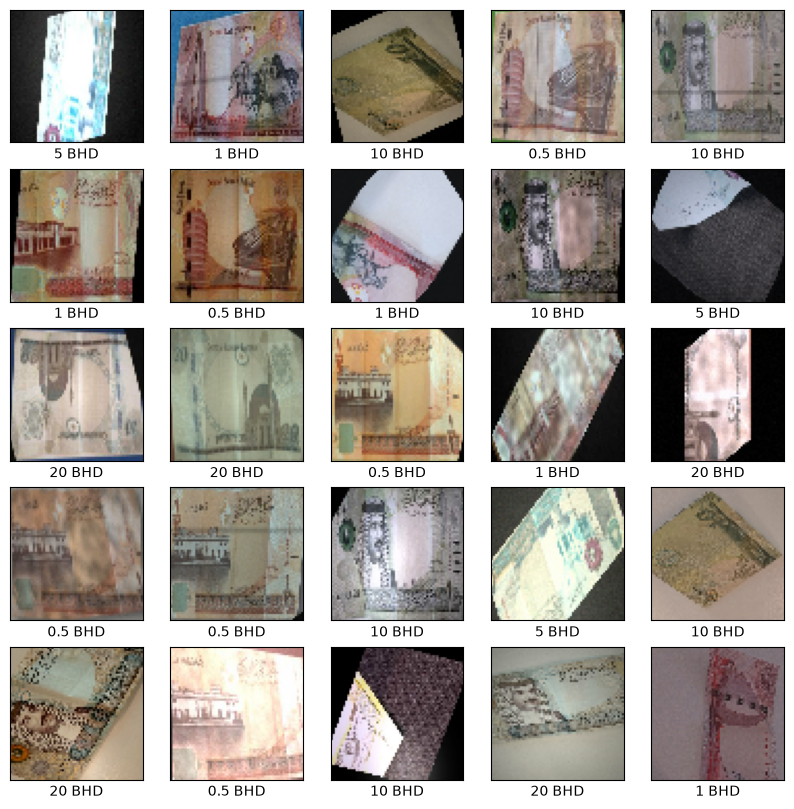

In [11]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [12]:
import pandas as pd
pd.Series([class_names[i] for i in y_train]).value_counts()

5 BHD      192
1 BHD      192
10 BHD     192
0.5 BHD    192
20 BHD     192
Name: count, dtype: int64

## Preprocessing

Same as `x_train/255` with Fashion MNIST.

In [13]:
x_train[0].max()

np.uint8(255)

In [14]:
x_train_scaled = x_train/255
x_val_scaled = x_val/255
x_test_scaled = x_test/255

x_train_scaled[0].max()

np.float64(1.0)

### Class Weights

This helps with imbalanced dataset.

In [15]:
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced",
                                     classes=np.unique(y_train), y=y_train)
class_weights

array([1., 1., 1., 1., 1.])

In [16]:
# fit() needs a dictionary, not an array
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.0),
 1: np.float64(1.0),
 2: np.float64(1.0),
 3: np.float64(1.0),
 4: np.float64(1.0)}

In [17]:
# https://www.tensorflow.org/api_docs/python/tf/keras/utils/set_random_seed
# reproducible

from tensorflow.keras.utils import set_random_seed
import random

seed = 100

random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Stops when val_loss stops improving and restores the best weights,
# so a large number of epochs is safe.
#
# Important: I build a NEW EarlyStopping inside each fitting cell below.
# If you reuse the same one for all three models it remembers the best loss
# from the model before, so the next model looks like it never improves and
# it stops after only 10 epochs.

# Model 1: Sequential API

- one input, one output

In [19]:
# Seq API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

#Step2
# The images are colour, so the shape is (64, 64, 3) and not (64, 64)
model_seq = Sequential()
model_seq.add(Input(shape=(64, 64, 3)))
model_seq.add(Flatten())                     # image 3D -> 1D
model_seq.add(Dense(500, activation='relu')) # hidden layer
model_seq.add(Dense(200, activation='relu')) # hidden layer
model_seq.add(Dense(100, activation='relu')) # hidden layer

model_seq.add(Dense(5, activation='softmax')) # output layer -> number of classes

model_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     6,144,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,265,305 (23.90 MB)

 Trainable params: 6,265,305 (23.90 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Step3: Compile
# sparse_categorical_crossentropy

model_seq.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [21]:
# Step4: Fitting (Learning)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_seq = model_seq.fit(x_train_scaled, y_train,
                            validation_data=(x_val_scaled, y_val),
                            epochs=100, callbacks=[es],
                            class_weight=class_weights)

Epoch 1/100


 1/30 ━━━━━━━━━━━━━━━━━━━━ 2:40 6s/step - acc: 0.2500 - loss: 1.5958

 2/30 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - acc: 0.2344 - loss: 4.6048

 3/30 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - acc: 0.2708 - loss: 6.1960

 4/30 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - acc: 0.2500 - loss: 6.2101

...

27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - acc: 0.7766 - loss: 0.5947

28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - acc: 0.7667 - loss: 0.6065

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.7683 - loss: 0.6105

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.7719 - loss: 0.6057

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - acc: 0.7719 - loss: 0.6057 - val_acc: 0.5875 - val_loss: 1.2522


## History (Sequential)

In [22]:
history_seq_df = pd.DataFrame(history_seq.history)
history_seq_df.tail()

,acc,loss,val_acc,val_loss
21,0.717708,0.734306,0.512500,1.365160
22,0.750000,0.674139,0.533333,1.308294
23,0.751042,0.641779,0.533333,1.497563
24,0.718750,0.711952,0.508333,1.569311
25,0.771875,0.605674,0.587500,1.252182


<Axes: title={'center': 'Sequential: accuracy'}>

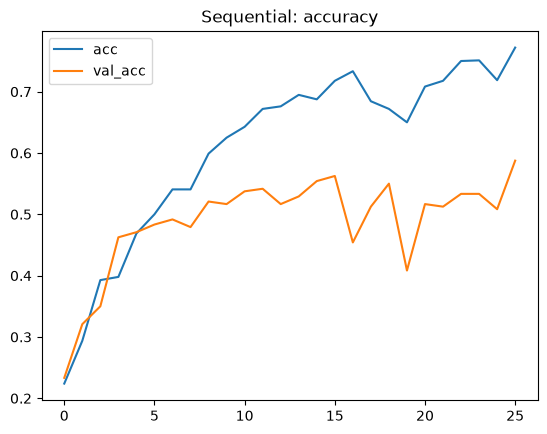

In [23]:
history_seq_df[['acc', 'val_acc']].plot(title="Sequential: accuracy")

<Axes: title={'center': 'Sequential: loss'}>

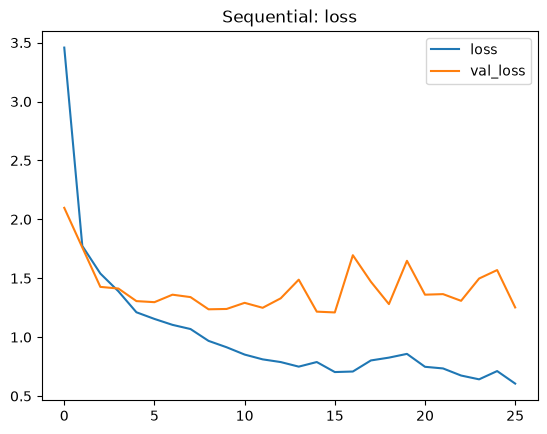

In [24]:
history_seq_df[['loss', 'val_loss']].plot(title="Sequential: loss")

## Prediction (Sequential)

In [25]:
pred = model_seq.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


array([[0.04636489, 0.18603005, 0.00122219, 0.752156  , 0.01422689]],
      dtype=float32)

In [26]:
max(model_seq.predict(x_test_scaled[:1])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


np.float32(0.752156)

In [27]:
np.argmax(model_seq.predict(x_test_scaled[:1])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


np.int64(3)

In [28]:
class_names[np.argmax(model_seq.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


'20 BHD'

In [29]:
#step5: Prediction

y_pred_seq = model_seq.predict(x_test_scaled)
y_pred_seq.shape

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


(300, 5)

In [30]:
for class_name, prop in zip(class_names, y_pred_seq[0]):
    print(class_name, prop)

0.5 BHD 0.046365187
1 BHD 0.18603104
10 BHD 0.0012221955
20 BHD 0.7521547
5 BHD 0.014226861


In [31]:
y_pred_seq_label = y_pred_seq.argmax(axis=1)
y_pred_seq_label

array([3, 0, 3, 4, 4, 0, 4, 1, 1, 4, 3, 3, 1, 1, 0, 2, 3, 0, 0, 3, 0, 4,
       4, 4, 2, 2, 4, 3, 4, 3, 3, 2, 0, 3, 4, 4, 3, 4, 3, 3, 1, 3, 1, 1,
       2, 3, 3, 2, 3, 1, 3, 0, 3, 3, 3, 2, 1, 3, 0, 3, 0, 2, 0, 3, 3, 4,
       3, 4, 3, 3, 2, 1, 3, 3, 3, 2, 3, 2, 0, 0, 0, 3, 4, 3, 0, 3, 3, 3,
       4, 1, 0, 3, 0, 3, 3, 3, 3, 3, 3, 0, 3, 1, 0, 3, 3, 3, 2, 4, 4, 0,
       2, 3, 0, 3, 0, 0, 0, 0, 0, 3, 3, 1, 4, 0, 3, 2, 3, 3, 3, 3, 3, 4,
       2, 3, 0, 0, 0, 3, 3, 3, 3, 4, 0, 3, 3, 4, 0, 1, 2, 3, 3, 4, 3, 3,
       3, 3, 3, 0, 3, 3, 0, 4, 0, 1, 3, 1, 0, 4, 3, 3, 3, 2, 2, 3, 4, 3,
       0, 3, 1, 0, 0, 0, 3, 4, 3, 3, 3, 0, 2, 3, 3, 3, 3, 3, 0, 1, 4, 3,
       4, 0, 0, 4, 3, 4, 4, 4, 3, 4, 4, 4, 3, 3, 3, 1, 4, 4, 4, 3, 4, 3,
       3, 3, 4, 4, 4, 0, 2, 4, 0, 2, 4, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3,
       2, 0, 3, 0, 0, 2, 2, 3, 0, 3, 4, 4, 3, 4, 3, 3, 3, 3, 4, 3, 3, 4,
       4, 3, 3, 3, 3, 1, 3, 4, 3, 3, 0, 0, 3, 0, 3, 1, 4, 3, 3, 3, 4, 1,
       1, 4, 3, 0, 3, 1, 0, 3, 0, 3, 3, 4, 1, 0])

## Eval (Sequential)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred_seq_label)

0.5966666666666667

In [33]:
model_seq.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.4688 - loss: 1.2036

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.5972 - loss: 1.1455 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.5967 - loss: 1.1460


[1.146028995513916, 0.596666693687439]

## Error Analysis (Sequential)

In [34]:
print(classification_report(y_test, y_pred_seq_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.77      0.73      0.75        60
       1 BHD       0.88      0.37      0.52        60
      10 BHD       0.85      0.37      0.51        60
      20 BHD       0.38      0.85      0.52        60
       5 BHD       0.71      0.67      0.69        60

    accuracy                           0.60       300
   macro avg       0.72      0.60      0.60       300
weighted avg       0.72      0.60      0.60       300



In [35]:
conf_seq = confusion_matrix(y_test, y_pred_seq_label, labels=range(len(class_names)))
conf_seq

array([[44,  2,  0, 13,  1],
       [ 8, 22,  2, 24,  4],
       [ 3,  1, 22, 29,  5],
       [ 2,  0,  1, 51,  6],
       [ 0,  0,  1, 19, 40]])

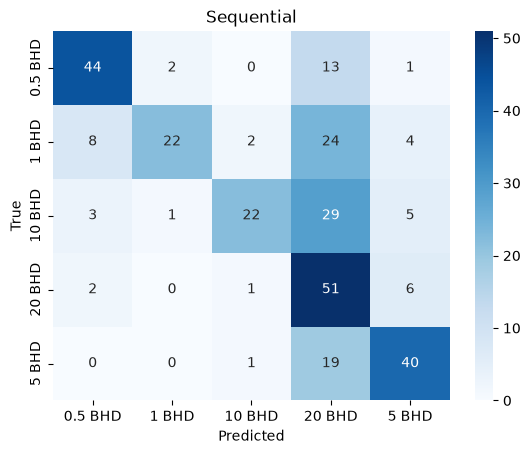

In [36]:
import seaborn as sns

sns.heatmap(conf_seq, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Sequential")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

number wrong: 121


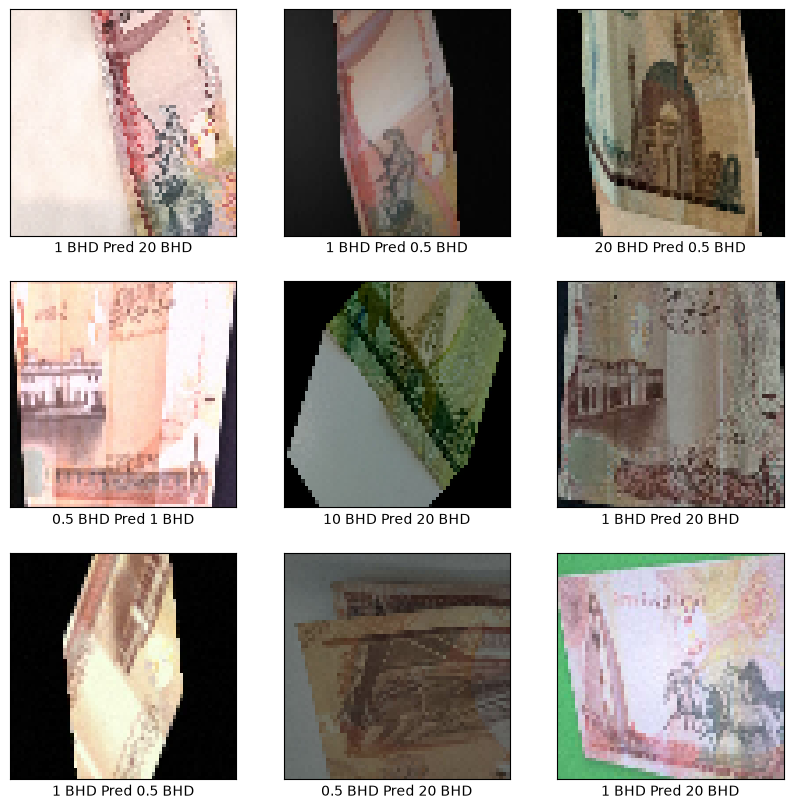

In [37]:
idx = np.where(y_test != y_pred_seq_label)[0]   # all the img the model got wrong
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_seq_label[idx[i]]]}")
plt.show()

# Model 2: Functional API

Same architecture as the Sequential model, written a different way.

In [38]:
# STep1: Import
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

# Step 2
inputs = Input(shape=(64, 64, 3))

x = Flatten()(inputs)
x = Dense(500, activation='relu')(x)
x = Dense(200, activation='relu')(x)
x = Dense(100, activation='relu')(x)

outputs = Dense(5, activation='softmax')(x)

model_func = Model(inputs=inputs, outputs=outputs)

model_func.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │     6,144,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,265,305 (23.90 MB)

 Trainable params: 6,265,305 (23.90 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.utils import plot_model
plot_model(model_func, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [40]:
# STep3: Compile
model_func.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [41]:
#STep4: Fitting
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_func = model_func.fit(x_train_scaled, y_train,
                              validation_data=(x_val_scaled, y_val),
                              epochs=100, callbacks=[es],
                              class_weight=class_weights)

Epoch 1/100


 1/30 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - acc: 0.2188 - loss: 1.8227

 2/30 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - acc: 0.2344 - loss: 5.4835

 3/30 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - acc: 0.1875 - loss: 8.2895

 4/30 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - acc: 0.2109 - loss: 8.5284

...

27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.7523 - loss: 0.6583

28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.7489 - loss: 0.6712

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.7489 - loss: 0.6703

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.7521 - loss: 0.6662

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - acc: 0.7521 - loss: 0.6662 - val_acc: 0.5542 - val_loss: 1.2808


## History (Functional)

In [42]:
history_func_df = pd.DataFrame(history_func.history)
history_func_df.tail()

,acc,loss,val_acc,val_loss
20,0.759375,0.626577,0.612500,1.091532
21,0.784375,0.578561,0.604167,1.148227
22,0.771875,0.569763,0.583333,1.142197
23,0.768750,0.640009,0.583333,1.352162
24,0.752083,0.666165,0.554167,1.280792


<Axes: title={'center': 'Functional: accuracy'}>

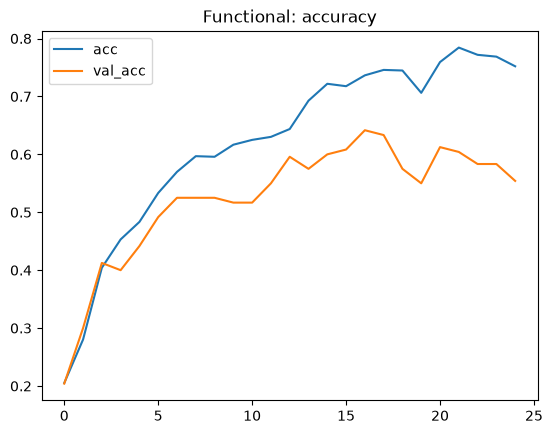

In [43]:
history_func_df[['acc', 'val_acc']].plot(title="Functional: accuracy")

<Axes: title={'center': 'Functional: loss'}>

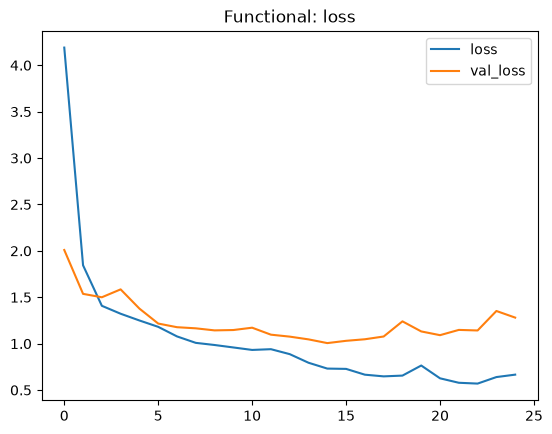

In [44]:
history_func_df[['loss', 'val_loss']].plot(title="Functional: loss")

## Prediction (Functional)

In [45]:
pred = model_func.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


array([[0.16026457, 0.74103415, 0.00858671, 0.08790272, 0.00221188]],
      dtype=float32)

In [46]:
class_names[np.argmax(model_func.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


'1 BHD'

In [47]:
y_pred_func = model_func.predict(x_test_scaled)
y_pred_func_label = y_pred_func.argmax(axis=1)
y_pred_func_label

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([1, 1, 2, 4, 1, 0, 4, 1, 1, 4, 2, 1, 1, 1, 0, 2, 0, 1, 0, 1, 0, 4,
       1, 4, 2, 2, 4, 2, 4, 1, 1, 2, 0, 2, 4, 4, 2, 4, 3, 2, 1, 2, 1, 1,
       2, 2, 3, 2, 2, 1, 3, 0, 3, 1, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 2, 4,
       2, 4, 0, 3, 2, 1, 0, 3, 2, 2, 1, 2, 1, 0, 0, 0, 4, 2, 0, 3, 1, 2,
       4, 1, 0, 2, 0, 1, 3, 1, 2, 1, 2, 0, 0, 1, 0, 2, 1, 3, 2, 4, 4, 0,
       2, 3, 1, 2, 0, 0, 0, 0, 0, 1, 3, 1, 4, 0, 2, 2, 2, 1, 3, 1, 1, 4,
       2, 2, 0, 0, 0, 2, 3, 3, 3, 4, 0, 3, 1, 2, 0, 1, 2, 3, 4, 2, 0, 1,
       1, 3, 3, 0, 2, 2, 0, 4, 0, 1, 1, 1, 0, 1, 4, 2, 0, 2, 2, 2, 4, 4,
       1, 2, 1, 0, 0, 0, 1, 4, 1, 3, 3, 0, 2, 3, 3, 3, 2, 3, 0, 1, 1, 1,
       4, 1, 0, 1, 1, 4, 4, 1, 2, 4, 2, 4, 2, 3, 1, 1, 2, 1, 4, 2, 4, 3,
       2, 3, 4, 4, 4, 0, 2, 4, 2, 2, 4, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3,
       2, 0, 2, 0, 1, 2, 2, 3, 0, 0, 4, 4, 0, 4, 2, 3, 3, 1, 4, 2, 3, 4,
       4, 1, 3, 3, 3, 1, 1, 4, 1, 0, 0, 0, 3, 0, 3, 1, 4, 3, 3, 1, 4, 1,
       1, 4, 1, 0, 1, 1, 0, 2, 0, 3, 1, 4, 1, 0])

## Eval (Functional)

In [48]:
accuracy_score(y_test, y_pred_func_label)

0.6666666666666666

In [49]:
model_func.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc: 0.5938 - loss: 1.0693

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6758 - loss: 0.9117 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.6667 - loss: 0.9403


[0.9403418898582458, 0.6666666865348816]

## Error Analysis (Functional)

In [50]:
print(classification_report(y_test, y_pred_func_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.76      0.75      0.76        60
       1 BHD       0.58      0.72      0.64        60
      10 BHD       0.56      0.70      0.62        60
      20 BHD       0.70      0.52      0.60        60
       5 BHD       0.81      0.65      0.72        60

    accuracy                           0.67       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.68      0.67      0.67       300



In [51]:
conf_func = confusion_matrix(y_test, y_pred_func_label, labels=range(len(class_names)))
conf_func

array([[45,  9,  4,  1,  1],
       [ 7, 43,  7,  2,  1],
       [ 4,  7, 42,  5,  2],
       [ 3,  8, 13, 31,  5],
       [ 0,  7,  9,  5, 39]])

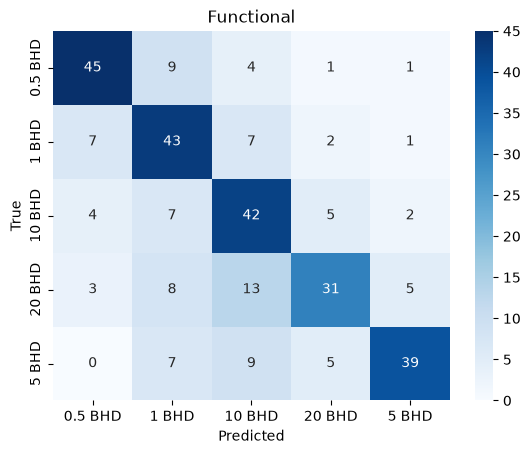

In [52]:
sns.heatmap(conf_func, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Functional")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

number wrong: 100


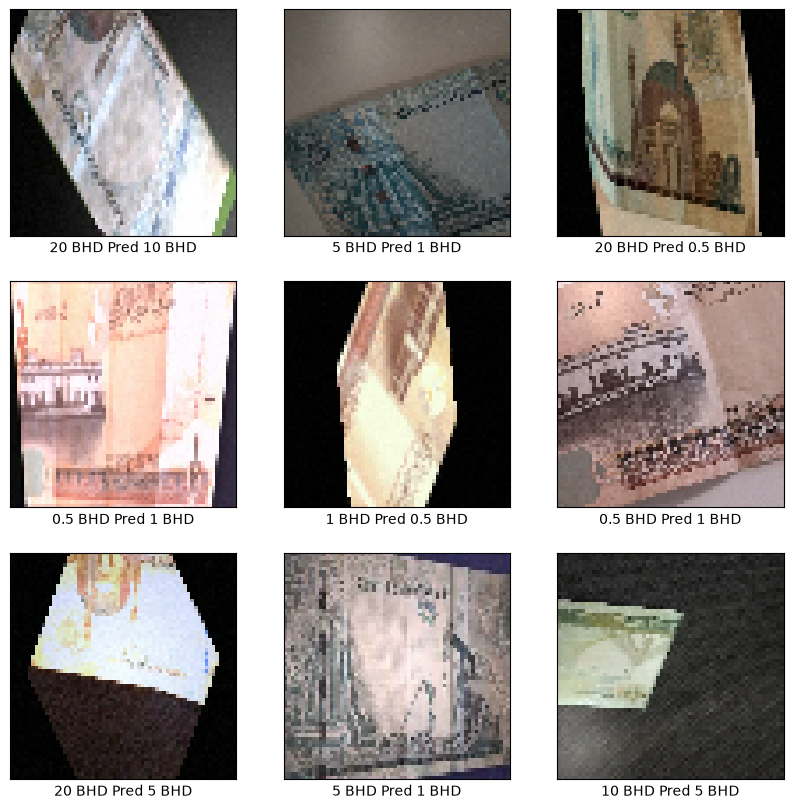

In [53]:
idx = np.where(y_test != y_pred_func_label)[0]
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_func_label[idx[i]]]}")
plt.show()

# Model 3: CNN

`Flatten` straight after the input throws away the 2D structure of the image:
pixel (0,0) and pixel (0,1) become unrelated numbers in a long list.

`Conv2D` looks at small neighbourhoods instead, so it can learn edges, patterns
and the printed numbers on the note. It also uses far fewer parameters, because
the same filter is reused across the whole image.

I also flip, turn, zoom and move the picture while training. Two reasons:

1. Almost all our pictures are close-ups where the note fills the frame, but in
   the app the customer's note is smaller and off to one side.
2. I tested the model on pictures of Bahraini notes from Wikipedia, which are
   different notes from the ones I scanned. When the note filled the frame it
   got 4 out of 5 right, but when the note was small it was no better than
   guessing, and it answered with 99% confidence anyway. The reason is that
   when the note is small most of the picture is background, and the model was
   really going by the overall colour.

I tried the same layers on the two Dense models and they got worse, which makes
sense: after `Flatten` a moved note is just a different list of numbers, but
`Conv2D` can still find it wherever it is.

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation

model_cnn = Sequential()
model_cnn.add(Input(shape=(64, 64, 3)))

# Change the picture a bit every epoch. These layers only work while training.
# I tested a few strengths and this one was the best: a bigger zoom range than
# I first tried, because in the app the note is often small in the picture.
model_cnn.add(RandomFlip("horizontal"))
model_cnn.add(RandomRotation(0.15))
model_cnn.add(RandomZoom(0.4))
model_cnn.add(RandomTranslation(0.2, 0.2))

model_cnn.add(Conv2D(32, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))
model_cnn.add(Conv2D(64, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))
model_cnn.add(Conv2D(128, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))

model_cnn.add(Flatten())
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(128, activation='relu'))

model_cnn.add(Dense(5, activation='softmax'))

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [56]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = model_cnn.fit(x_train_scaled, y_train,
                            validation_data=(x_val_scaled, y_val),
                            epochs=100, callbacks=[es],
                            class_weight=class_weights)

Epoch 1/100


 1/30 ━━━━━━━━━━━━━━━━━━━━ 1:27 3s/step - acc: 0.2188 - loss: 1.6032

 2/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - acc: 0.2188 - loss: 1.6011

 3/30 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - acc: 0.2292 - loss: 1.6085

 4/30 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - acc: 0.2188 - loss: 1.6131

...

27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.7755 - loss: 0.5403

28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.7723 - loss: 0.5461

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.7748 - loss: 0.5399

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - acc: 0.7750 - loss: 0.5385

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - acc: 0.7750 - loss: 0.5385 - val_acc: 0.7333 - val_loss: 0.6393


## History (CNN)

In [57]:
history_cnn_df = pd.DataFrame(history_cnn.history)
history_cnn_df.tail()

,acc,loss,val_acc,val_loss
46,0.764583,0.594067,0.687500,0.852566
47,0.781250,0.561857,0.770833,0.567979
48,0.808333,0.514564,0.783333,0.575768
49,0.815625,0.498258,0.737500,0.682279
50,0.775000,0.538540,0.733333,0.639319


<Axes: title={'center': 'CNN: accuracy'}>

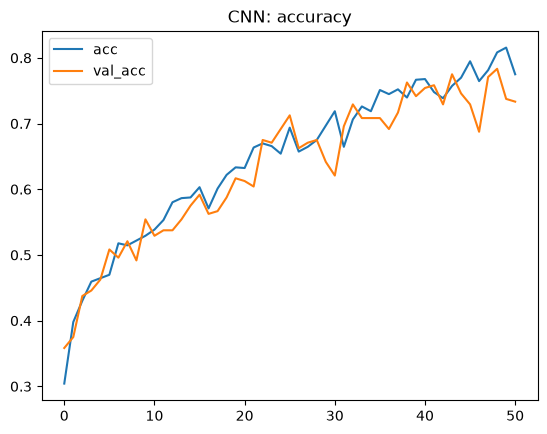

In [58]:
history_cnn_df[['acc', 'val_acc']].plot(title="CNN: accuracy")

<Axes: title={'center': 'CNN: loss'}>

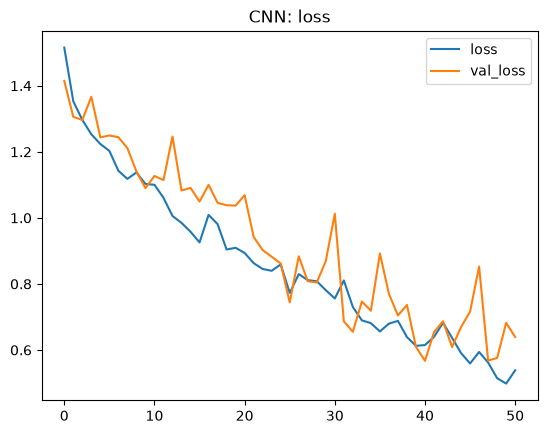

In [59]:
history_cnn_df[['loss', 'val_loss']].plot(title="CNN: loss")

## Prediction (CNN)

In [60]:
pred = model_cnn.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


array([[1.2096024e-06, 9.9998903e-01, 2.9593616e-10, 9.7540878e-06,
        6.9279094e-09]], dtype=float32)

In [61]:
class_names[np.argmax(model_cnn.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


'1 BHD'

In [62]:
y_pred_cnn = model_cnn.predict(x_test_scaled)
y_pred_cnn_label = y_pred_cnn.argmax(axis=1)
y_pred_cnn_label

 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step

 4/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 

 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([1, 1, 4, 4, 4, 3, 4, 1, 3, 4, 2, 1, 0, 1, 0, 2, 0, 3, 0, 1, 3, 3,
       4, 2, 2, 4, 2, 3, 4, 2, 1, 3, 0, 3, 4, 4, 3, 4, 3, 2, 1, 2, 1, 2,
       2, 2, 3, 2, 3, 1, 4, 0, 3, 1, 3, 2, 1, 2, 0, 2, 0, 2, 0, 1, 2, 4,
       3, 2, 2, 1, 2, 1, 0, 3, 2, 3, 4, 1, 3, 0, 0, 2, 3, 4, 0, 1, 3, 4,
       3, 1, 3, 1, 0, 3, 3, 3, 3, 3, 3, 3, 0, 1, 0, 3, 2, 3, 2, 4, 4, 1,
       4, 3, 1, 2, 0, 0, 0, 0, 0, 1, 4, 1, 4, 0, 2, 2, 3, 1, 3, 3, 3, 4,
       2, 3, 0, 0, 0, 1, 4, 3, 4, 4, 0, 3, 3, 2, 0, 1, 2, 3, 4, 2, 1, 1,
       3, 3, 3, 0, 3, 3, 3, 4, 1, 1, 2, 0, 0, 1, 1, 3, 3, 2, 2, 4, 4, 4,
       1, 4, 1, 3, 0, 0, 4, 4, 1, 3, 4, 0, 2, 3, 2, 3, 0, 3, 0, 1, 4, 1,
       4, 0, 0, 3, 1, 2, 4, 1, 4, 2, 3, 3, 3, 3, 1, 1, 1, 2, 4, 2, 4, 3,
       1, 3, 4, 4, 4, 0, 2, 4, 2, 2, 4, 3, 2, 2, 3, 2, 4, 3, 2, 3, 2, 3,
       2, 2, 3, 0, 3, 2, 2, 3, 0, 3, 4, 4, 1, 4, 4, 3, 4, 3, 4, 3, 3, 4,
       4, 1, 4, 3, 3, 1, 3, 3, 3, 1, 0, 3, 3, 1, 3, 1, 4, 2, 3, 2, 4, 1,
       0, 4, 3, 1, 3, 1, 0, 4, 0, 3, 1, 4, 1, 1])

In [63]:
for class_name, prop in zip(class_names, y_pred_cnn[0]):
    print(class_name, prop)

0.5 BHD 1.2095967e-06
1 BHD 0.99998903
10 BHD 2.959356e-10
20 BHD 9.754088e-06
5 BHD 6.9279094e-09


## Eval (CNN)

In [64]:
accuracy_score(y_test, y_pred_cnn_label)

0.79

In [65]:
model_cnn.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.6875 - loss: 0.6844

 3/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.7708 - loss: 0.5741

 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.7760 - loss: 0.5757

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.7891 - loss: 0.5503

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.7900 - loss: 0.5477


[0.5477476716041565, 0.7900000214576721]

## Error Analysis (CNN)

In [66]:
print(classification_report(y_test, y_pred_cnn_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.91      0.67      0.77        60
       1 BHD       0.89      0.83      0.86        60
      10 BHD       0.83      0.75      0.79        60
      20 BHD       0.57      0.82      0.67        60
       5 BHD       0.88      0.88      0.88        60

    accuracy                           0.79       300
   macro avg       0.82      0.79      0.80       300
weighted avg       0.82      0.79      0.80       300



In [67]:
conf_cnn = confusion_matrix(y_test, y_pred_cnn_label, labels=range(len(class_names)))
conf_cnn

array([[40,  4,  0, 16,  0],
       [ 4, 50,  0,  6,  0],
       [ 0,  1, 45, 12,  2],
       [ 0,  0,  6, 49,  5],
       [ 0,  1,  3,  3, 53]])

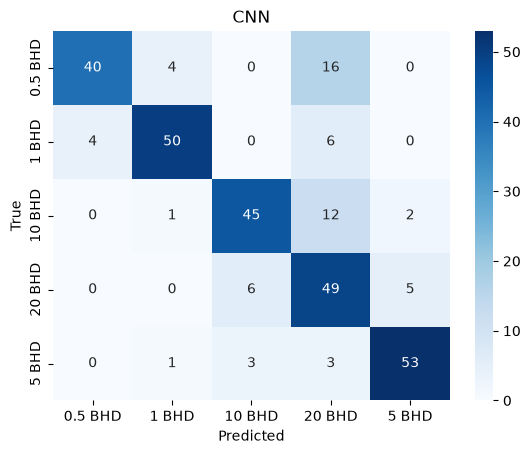

In [68]:
sns.heatmap(conf_cnn, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

number wrong: 63


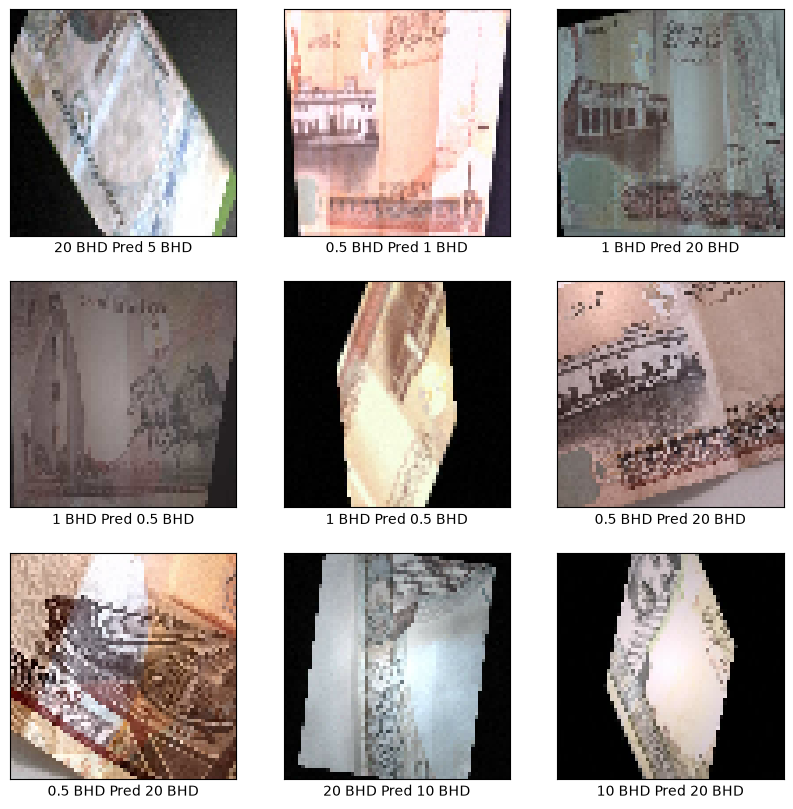

In [69]:
idx = np.where(y_test != y_pred_cnn_label)[0]
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_cnn_label[idx[i]]]}")
plt.show()

# Comparing the Three Models

In [70]:
results = pd.DataFrame({
    'model': ['Sequential', 'Functional', 'CNN'],
    'parameters': [model_seq.count_params(), model_func.count_params(), model_cnn.count_params()],
    'test accuracy': [accuracy_score(y_test, y_pred_seq_label),
                      accuracy_score(y_test, y_pred_func_label),
                      accuracy_score(y_test, y_pred_cnn_label)]
})
results

,model,parameters,test accuracy
0,Sequential,6265305,0.596667
1,Functional,6265305,0.666667
2,CNN,683845,0.790000


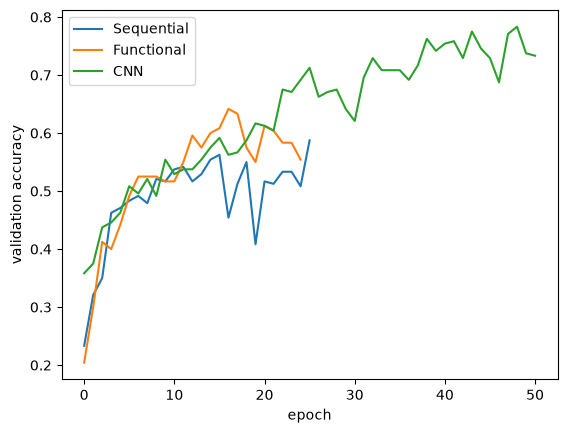

In [71]:
plt.plot(history_seq_df['val_acc'], label='Sequential')
plt.plot(history_func_df['val_acc'], label='Functional')
plt.plot(history_cnn_df['val_acc'], label='CNN')
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.show()

## Save the Best Model for the Streamlit App

In [72]:
model_cnn.save("currency_model.keras")
print("saved currency_model.keras")
print("copy this into the app:")
print(class_names)

saved currency_model.keras
copy this into the app:
['0.5 BHD', '1 BHD', '10 BHD', '20 BHD', '5 BHD']


In [73]:
if IN_COLAB:
    from google.colab import files
    files.download("currency_model.keras")